# Example 5.5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def spheric_pellet(n, phi2, Bi, tau):
    """
    Function that computes the time evolution of solute concentration
    in a porous spherical pellet with effective diffusivity D_eff,
    mass transfer coefficient k_m at the fluid side, and radius R.

    Input variables:
    n    : number of nodes in the finite-difference grid
    phi2 : Thiele modulus = k*R^2 / D_eff
    Bi   : Biot number for mass transfer = k_m*R / D_eff
    tau  : vector of dimensionless times where y(x,t) is computed

    Output variables:
    T : vector of integration times (equal to tau)
    Y : concentration values at the N+1 spatial nodes
    """

    # Grid definition
    N = n                      # number of grid segments
    dx = 1.0 / N               # grid spacing
    X = np.linspace(0.0, 1.0, N + 1)  # spatial domain

    beta = 3.0 + 2.0 * dx * Bi  # numerical factor

    # Initial condition
    Y0 = np.zeros(N + 1)
    Y0[-1] = 2.0 * dx * Bi / beta  # boundary-condition effect in IC

    # Time integration (ode113 equivalent)
    sol = solve_ivp(
        fun=lambda t, y: system(t, y, N, phi2, beta, X, dx),
        t_span=(tau[0], tau[-1]),
        y0=Y0,
        t_eval=tau,
        method="LSODA"
    )

    T = sol.t
    Y = sol.y.T   # shape: (len(tau), N+1)

    # Plot results
    styles = ['k-', 'kv', 'k*', 'k<', 'k--', 'k+']

    plt.plot(X, Y[0, :], styles[0])
    for i in range(1, len(T)):
        plt.plot(X, Y[i, :], styles[i % len(styles)],markerfacecolor='none')

    plt.title(
        f"Solution for Bi_m = {Bi} and Φ² = {phi2} with N = {N} elements"
    )
    plt.xlabel("Dimensionless radius x = r/R")
    plt.ylabel("Dimensionless concentration y(x, τ)")
    plt.legend([f"{t:.3g}" for t in T], loc="best")
    plt.grid(True)
    filename = 'Figure_5_7.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    return T, Y


def system(t, y, N, phi2, beta, X, dx):
    """
    Sub-function that defines the system of differential equations
    for the method of lines
    """

    yp = np.zeros(N + 1)

    for i in range(1, N):
        yp[i] = (
            (y[i - 1] - 2.0 * y[i] + y[i + 1]) / dx**2
            + (y[i + 1] - y[i - 1]) / (X[i] * dx)
            - phi2 * y[i]
        )

    # Boundary conditions
    yp[0] = (4.0 * yp[1] - yp[2]) / 3.0
    yp[N] = (4.0 * yp[N - 1] - yp[N - 2]) / beta

    return yp

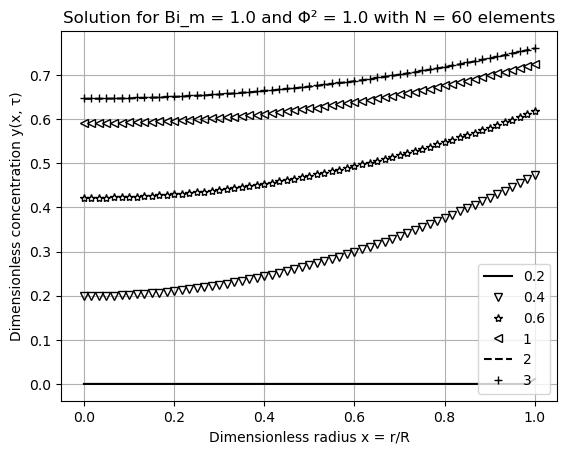

In [2]:
# running the script and plotting figure 5.7
n = 60
phi2 = 1.0
Bi = 1.0
tau = np.array([0.2, 0.4, 0.6, 1.0, 2.0, 3.0])

T, Y = spheric_pellet(n, phi2, Bi, tau)